## Introduction

The objective of this project is to predict which customers are likely to accept a personal loan offer.

This is a classification problem where:
- 1 = Customer accepts loan
- 0 = Customer does not accept loan

We analyze features like age, job, marital status, and balance to make predictions.


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [20]:
# Load the dataset
df = pd.read_csv('bank-full.csv', sep=';')   # Note: separator is semicolon (;)

print("Shape:", df.shape)
print(df.columns.tolist())
df.head()

Shape: (45211, 17)
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'y']


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [21]:
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())
print("\nTarget Distribution (Subscribed to Personal Loan):\n", 
      df['y'].value_counts(normalize=True))

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB
None

Missing Values:
 age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan 

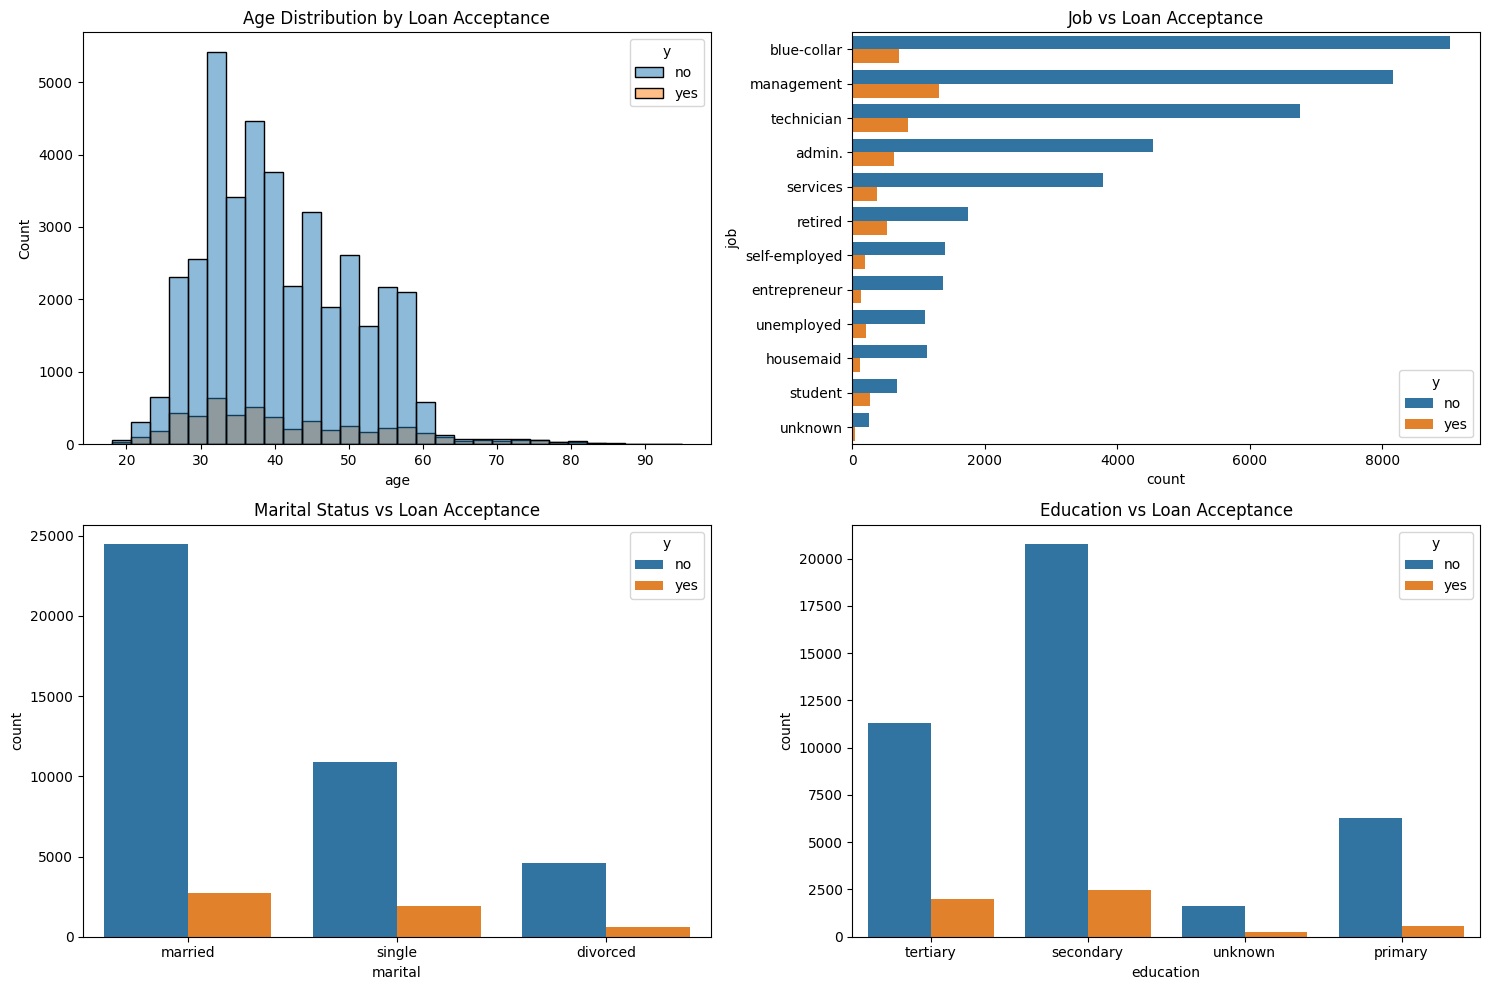

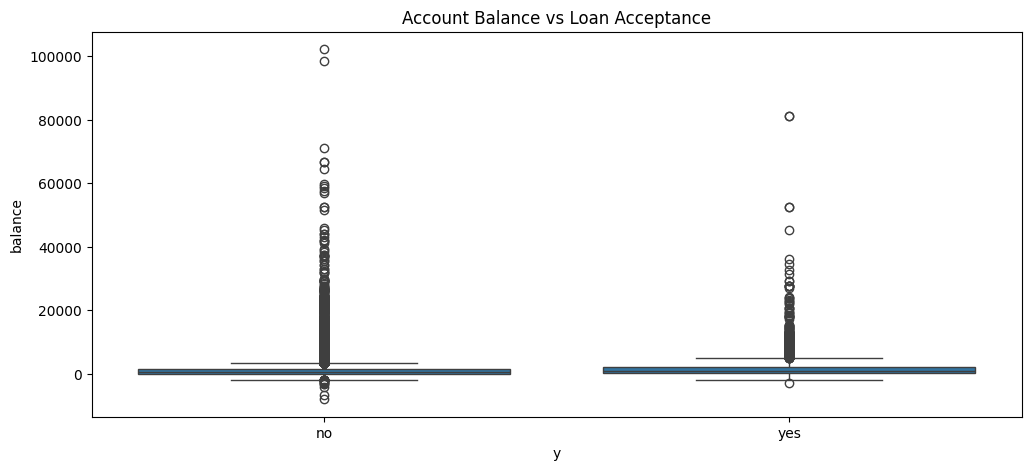

In [22]:
# Key Visualizations as per Task

plt.figure(figsize=(15, 10))

# Age Distribution
plt.subplot(2, 2, 1)
sns.histplot(data=df, x='age', hue='y', bins=30)
plt.title('Age Distribution by Loan Acceptance')

# Job
plt.subplot(2, 2, 2)
sns.countplot(data=df, y='job', hue='y', order=df['job'].value_counts().index)
plt.title('Job vs Loan Acceptance')

# Marital Status
plt.subplot(2, 2, 3)
sns.countplot(data=df, x='marital', hue='y')
plt.title('Marital Status vs Loan Acceptance')

# Education
plt.subplot(2, 2, 4)
sns.countplot(data=df, x='education', hue='y')
plt.title('Education vs Loan Acceptance')

plt.tight_layout()
plt.show()

# Balance & Campaign
plt.figure(figsize=(12,5))
sns.boxplot(x='y', y='balance', data=df)
plt.title('Account Balance vs Loan Acceptance')
plt.show()

In [23]:
# Encode target
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# One-hot encoding for categorical features
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 
                   'loan', 'contact', 'month', 'poutcome']
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("Final Shape after encoding:", df.shape)

Final Shape after encoding: (45211, 43)


In [24]:
X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

# Pipeline with Scaling
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42)
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8989

Confusion Matrix:
 [[9692  258]
 [ 885  468]]

Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.97      0.94      9950
           1       0.64      0.35      0.45      1353

    accuracy                           0.90     11303
   macro avg       0.78      0.66      0.70     11303
weighted avg       0.88      0.90      0.89     11303



In [25]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Decision Tree Model
dt_model = DecisionTreeClassifier(
    max_depth=8,           # You can tune this
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

print("=== Decision Tree Model Performance ===")
print("Accuracy:", round(accuracy_score(y_test, dt_pred), 4))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, dt_pred))
print("\nClassification Report:")
print(classification_report(y_test, dt_pred))

=== Decision Tree Model Performance ===
Accuracy: 0.8968

Confusion Matrix:
[[9566  384]
 [ 783  570]]

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.96      0.94      9950
           1       0.60      0.42      0.49      1353

    accuracy                           0.90     11303
   macro avg       0.76      0.69      0.72     11303
weighted avg       0.89      0.90      0.89     11303



In [26]:
print("=== MODEL COMPARISON ===")
print(f"Logistic Regression Accuracy : {round(accuracy_score(y_test, y_pred), 4)}")
print(f"Decision Tree Accuracy       : {round(accuracy_score(y_test, dt_pred), 4)}")

=== MODEL COMPARISON ===
Logistic Regression Accuracy : 0.8989
Decision Tree Accuracy       : 0.8968


=== Top 10 Most Important Features ===
             Feature  Importance
3           duration    0.469312
40  poutcome_success    0.234999
0                age    0.053440
5              pdays    0.042031
27   contact_unknown    0.034325
34         month_mar    0.031955
33         month_jun    0.029124
1            balance    0.026293
2                day    0.018001
37         month_oct    0.012386


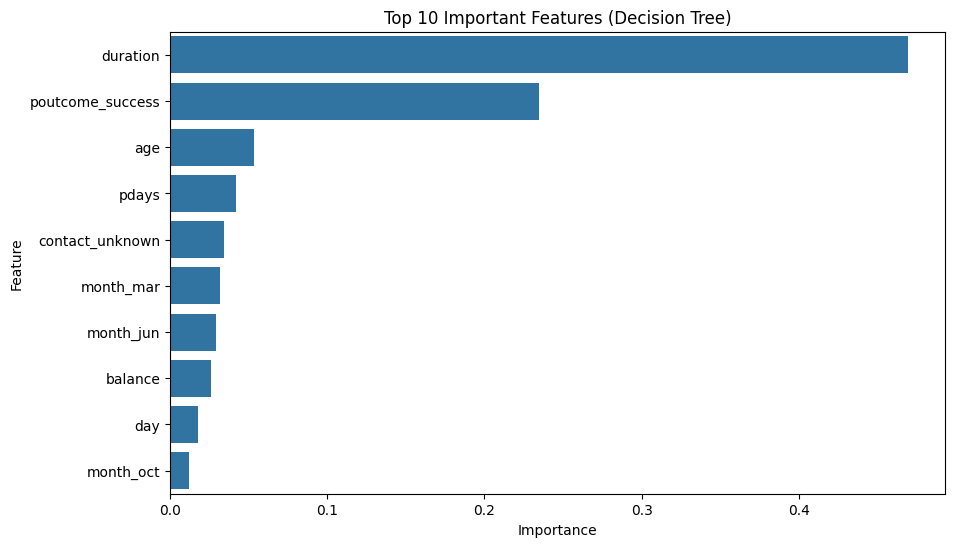

In [27]:
# Get Feature Importance
importances = dt_model.feature_importances_
feature_names = X_train.columns

# Top 10 Features
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

print("=== Top 10 Most Important Features ===")
print(feature_importance.head(10))

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance.head(10))
plt.title('Top 10 Important Features (Decision Tree)')
plt.show()

## Business Insights

- Customers with higher balance are more likely to accept loan offers
- Certain job categories (e.g., management) show higher acceptance rates
- Married customers have different behavior compared to single customers
- Age group also influences loan acceptance

These insights can help banks target the right customers.


## Conclusion

This project successfully predicted customer loan acceptance.

Key points:
- Logistic Regression performed well
- Customer demographics significantly influence decisions
- Model can help banks improve marketing strategies
